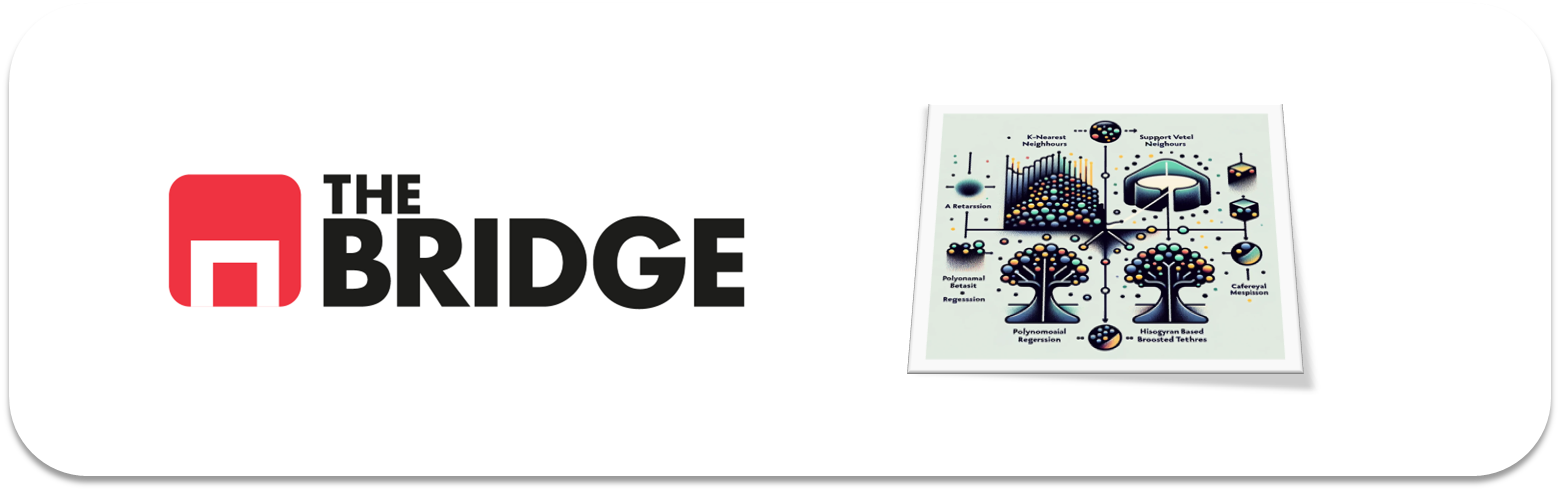

## PRACTICA OBLIGATORIA: **Repaso Aprendizaje Supervisado**

* La práctica obligatoria de esta unidad consiste en resolver sobre un mismo dataset un problema de clasificación y un problema de regresión. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import bootcampviztools as bt
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns

from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, make_scorer, precision_score, ConfusionMatrixDisplay,mean_absolute_percentage_error
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier, XGBRegressor

pd.options.mode.copy_on_write = True

C:\Users\maria\AppData\Local\Temp\ipykernel_16012\1774453089.py:17: Pandas4Warning: The 'mode.copy_on_write' option is deprecated. Copy-on-Write can no longer be disabled (it is always enabled with pandas >= 3.0), and setting the option has no impact. This option will be removed in pandas 4.0.
  pd.options.mode.copy_on_write = True


### #1 Explicación del dataset y carga de datos

Vamos a trabajar con el dataset "Wine Quality", que es un dataset en el que se recogen diversas características fisicoquímicas de las variades tinta y blanca del "Vinho verde" portugués. Las variables del dataset se describen a continuación


1. **Acidez fija**: La mayoría de los ácidos involucrados con el vino son fijos o no volátiles (no se evaporan fácilmente).
2. **Acidez volátil**: La cantidad de ácido acético en el vino, que en niveles demasiado altos puede llevar a un sabor desagradable a vinagre.
3. **Ácido cítrico**: Encontrado en pequeñas cantidades, el ácido cítrico puede añadir 'frescura' y sabor a los vinos.
4. **Azúcar residual**: Es la cantidad de azúcar restante después de que se detiene la fermentación, es raro encontrar vinos con menos de 1 gramo/litro y vinos con más de 45 gramos/litro se consideran dulces.
5. **Cloruros**: La cantidad de sal en el vino.
6. **Dióxido de azufre libre**: La porción libre de SO2 existe en equilibrio entre el SO2 molecular (como un gas disuelto) y el ion bisulfito; previene el crecimiento microbiano y la oxidación del vino.
7. **Dióxido de azufre total**: Es la cantidad de formas libres y ligadas de S02; en bajas concentraciones, el SO2 es en su mayoría indetectable en el vino, pero en concentraciones libres de más de 50 ppm, el SO2 se hace evidente en la nariz y el sabor del vino.
8. **Densidad**: La densidad del vino es cercana a la del agua dependiendo del porcentaje de alcohol y contenido de azúcar.
9. **pH**: Describe qué tan ácido o básico es un vino en una escala de 0 (muy ácido) a 14 (muy básico); la mayoría de los vinos están entre 3-4 en la escala de pH.
10. **Sulfatos**: Un aditivo del vino que puede contribuir a los niveles de dióxido de azufre (SO2), que actúa como un antimicrobiano y antioxidante.
11. **Alcohol**: El porcentaje de contenido de alcohol del vino.
12. **Calidad**: Una variable de salida (basada en datos sensoriales, puntuación entre 0 y 10).
13. **Class**: Si es blanco o tinto.



Carga el dataset "wines_dataset.csv", muestra sus primeras filas, su información general y define dos variables target una para clasificación que permita predecir la calidad del vino según el resto de propiedas y otra variable target para regresión que permita predecir el grado alcohólico del vino a partir del resto de propiedades. 

El **objetivo de negocio en el primer problema** será anticipar la posible clasificación de sus vinos por los catadores profesionales y a partir de ahí poder planificar la producción, distribución y precio a poner a cada vino. En este sentido, el "cliente" nos dice que le gustaría poder clasificar correctamente lo mejor posible en media  (que interpretamos como el mejor recall medio posible).

El **objetivo de negocio en el segundo problema** (bastante artificial) es poder hacer simulaciones de posibles vinos futuros para saber cómo conseguir variedades más o menos alcohólicas para atender mercados diferentes. En este sentido, les interesa equivocarse lo menos posible porcentualmente sobre el grado alochólico real.

Muestra la distribución de ambos targets y haz un pequeño assesment previo de cada problema. NOTA: El dataset está limpio y sin valores faltantes.

Primeras Filas...


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,class
0,8.5,0.21,0.26,9.25,0.034,73.0,142.0,0.99450,3.05,0.37,11.4,6,white
1,8.3,0.16,0.37,7.90,0.025,38.0,107.0,0.99306,2.93,0.37,11.9,6,white
2,6.8,0.18,0.38,1.40,0.038,35.0,111.0,0.99180,3.32,0.59,11.2,7,white
3,6.1,0.26,0.25,2.90,0.047,289.0,440.0,0.99314,3.44,0.64,10.5,3,white
4,7.5,0.63,0.27,2.00,0.083,17.0,91.0,0.99616,3.26,0.58,9.8,6,red



Información General...
<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  class                 6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB
None

Distribución de Calidad (Clasificación)
quality


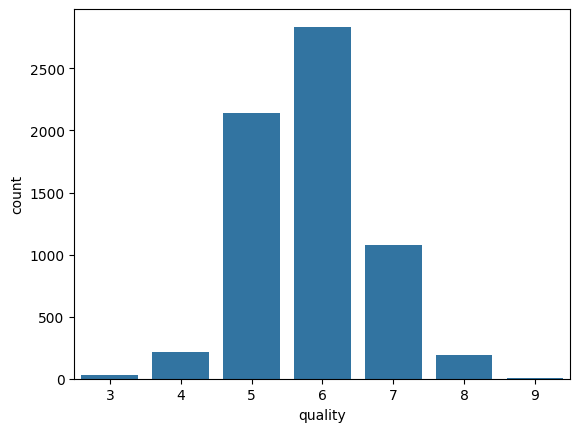


Distribución de Alcohol (Regresión)
count    6497.000000
mean       10.491801
std         1.192712
min         8.000000
25%         9.500000
50%        10.300000
75%        11.300000
max        14.900000
Name: alcohol, dtype: float64


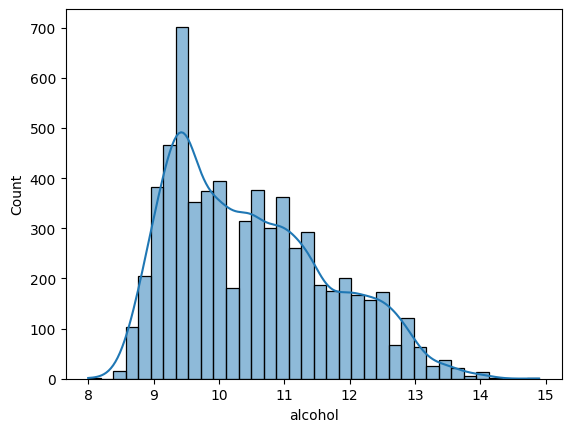

In [5]:
# 1. Cargo el dataset
df = pd.read_csv("data/wines_dataset.csv", sep = "|")

# 2. Muestro las primeras filas e información general
print("Primeras Filas...")
display(df.head())

print("\nInformación General...")
print(df.info())

# No se requiere limpieza, por lo que menciona el enunciado de que no hay nulos
# Sí la columna 'Class' (blanco o tinto) es categórica (texto), la codificamos:
# 1. Limpiamos posibles espacios en blanco invisibles en el texto
df['class'] = df['class'].astype(str).str.strip()

# 2. Forzamos el mapeo
df['class'] = df['class'].map({'white': 0, 'red': 1})

# 3. Definir las variables para cada problema
# Objetivo 1 (Clasificación): Predecir 'Calidad' usando el resto de propiedades (excepto alcohol si es necesario, o incluyéndolo según la descripción)
# El enunciado de regresión dice: "a partir de las características... y la puntuación de calidad".
# Para clasificación usaremos todas las propiedades químicas menos la calidad en X.

X_clas = df.drop(columns=['quality'])
y_clas = df['quality']

# Objetivo 2 (Regresión): Predecir 'Alcohol' a partir del resto de variables (incluyendo calidad)
X_reg = df.drop(columns=['alcohol'])
y_reg = df['alcohol']

# 4. Muestro la distribución de ambos targets
print("\nDistribución de Calidad (Clasificación)")
print(y_clas.value_counts().sort_index())
sns.countplot(x=y_clas)
plt.show()

print("\nDistribución de Alcohol (Regresión)")
print(y_reg.describe())
sns.histplot(y_reg, kde=True)
plt.show()


### #2 Modelado para clasificación

Crea un modelo que permita clasificar lo mejor posible los vinos en función de su calidad, o dicho de otro modo que prediga de la mejor manera posible la calidad de un vino a partir de sus propiedades químicas. ***Considéralo un problema de clasificación***, donde los valores de calidad son las clases a predecir. Puedes utilizar los modelos que creas conveniente, al menos tres, y utiliza un KNN como modelo baseline, prueba al menos con 2 valores de K. Intenta mejorar el "recall medio" con las técnicas que creas conveniente. Compara los modelos utilizando validación cruzada con o sin optimización previa de hiperparámetros (aunque en la sesión en vivo por limitación de tiempos sólo lo haremos con validación cruzada). El modelo elegido si tiene que tener un ejemplo de optimización de parámetros.

Evalúa el modelo, analiza los errores y propón algún mecanismo de mejora aunque sea sólo un esbozo.

In [3]:
# El objetivo de negocio es maximizar el recall medio (macro o weighted dependiendo si se busca equilibrar las clases)
# Baseline obligatorio: KNN probando al menos 2 valores de K
# Probar al menos 3 tipos de modelos
# Comparar usando validación cruzada e incluir un ejemplo de optimización de hiperparámetros.

Evaluando Modelos con Validación Cruzada...


c:\Users\maria\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


KNN (K=3) - Recall medio en CV: 0.2994


c:\Users\maria\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


KNN (K=7) - Recall medio en CV: 0.2736


c:\Users\maria\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Random Forest - Recall medio en CV: 0.3657


c:\Users\maria\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(



Mejor Random Forest optimizado en CV: 0.3672
Mejores parámetros: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}

Evaluación Final en Test...
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.67      0.14      0.23        43
           5       0.72      0.75      0.74       428
           6       0.65      0.78      0.71       567
           7       0.70      0.52      0.60       216
           8       0.93      0.33      0.49        39
           9       0.00      0.00      0.00         1

    accuracy                           0.68      1300
   macro avg       0.52      0.36      0.39      1300
weighted avg       0.69      0.68      0.67      1300



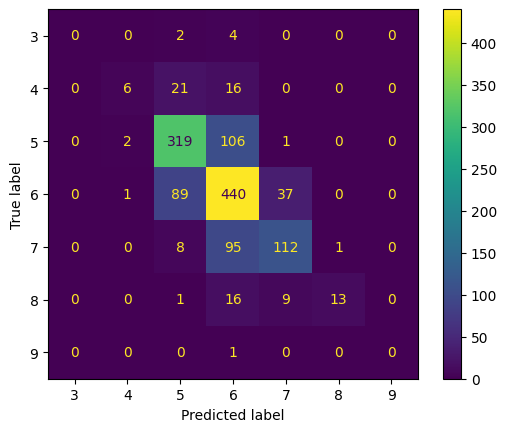

In [6]:
# Dividimos en train y test para la evaluación final
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clas, y_clas, test_size=0.2, random_state=42, stratify=y_clas)

# Como usamos KNN y modelos lineales, es obligatorio que escalemos los datos
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

# Definimos el scorer para el "recall medio" (macro recall)
recall_scorer = make_scorer(precision_score, average='macro', zero_division=0) # El enunciado pide recall medio, puedes cambiar a recall_score si prefieres

print("Evaluando Modelos con Validación Cruzada...")

# 1. Baseline: KNN con K=3 y K=7
for k in [3, 7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_c_scaled, y_train_c, cv=5, scoring='recall_macro')
    print(f"KNN (K={k}) - Recall medio en CV: {scores.mean():.4f}")

# 2. Segundo Modelo: Random Forest
rf_clf = RandomForestClassifier(random_state=42)
scores_rf = cross_val_score(rf_clf, X_train_c, y_train_c, cv=5, scoring='recall_macro') # Árboles no necesitan escalado estricto pero se puede usar igual
print(f"Random Forest - Recall medio en CV: {scores_rf.mean():.4f}")

# 3. Tercer Modelo: Logistic Regression u Optimización de Hyperparámetros (GridSearch)
# Vamos a optimizar un LightGBM o Random Forest como ejemplo de optimización
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='recall_macro', n_jobs=-1)
grid_search.fit(X_train_c, y_train_c)

best_rf = grid_search.best_estimator_
print(f"\nMejor Random Forest optimizado en CV: {grid_search.best_score_:.4f}")
print("Mejores parámetros:", grid_search.best_params_)

# --- Evaluación final del mejor modelo ---
print("\nEvaluación Final en Test...")
y_pred_c = best_rf.predict(X_test_c)
print(classification_report(y_test_c, y_pred_c, zero_division=0))

# Matriz de confusión
ConfusionMatrixDisplay.from_estimator(best_rf, X_test_c, y_test_c)
plt.show()

In [7]:
# Motivo de los warnings: Estos ocurren porque tenemos clases (puntuaciones de calidad de vino) extremadamente raras. Por ejemplo, en todo el dataset de entrenamiento solo hay 4 vinos con una calidad específica. 
# Al intentar hacer una validación cruzada dividiendo los datos en 5 bloques (cv=5), matemáticamente es imposible meter al menos un vino de esa calidad en cada uno de los 5 bloques.

Análisis del Reporte de Clasificación: si miramos la columna 'support' (el número de vinos reales de cada calidad enn el grupo de test):
- Las clases 5 ($428$ vinos) y 6 ($567$ vinos) dominan por completo el dataset.
- Las clases extremas como la 3 ($6$ vinos) o la 9 ($1$ vino) casi no existen.  

¿Cómo afecta esto al modelo?
- El Recall (sensibilidad) para las clases 3 y 9 es 0.00. El modelo las ignora por completo porque le sale más a cuenta predecir siempre que un vino es de calidad 5 o 6 para equivocarse poco en general.

- Mi macro avg recall (el recall medio que me pide el negocio monitorizar) se queda en 0.36. Es bajo debido a que el modelo falla estrepitosamente con las clases minoritarias.

Análisis de la MAtriz de Confusión: La diagonal muestra los aciertos siguientes:
- Clasificó muy bien los de calidad 5 ($319$ aciertos) y 6 ($440$ aciertos).
- Observamos la fila de la calidad 3: de los 6 vinos reales que había, clasificó 2 como calidad 5 y 4 como calidad 6. -> Ninguno en su celda correcta
- Lo mismo con el único vino de calidad 9: lo predijo como calidad 6.

Propuesta de mejora (clasificación)  
El dataset sufre un desbalance de clases (la gran mayoría de los vinos se concentran en las calidades 5 y 6). Como consecuencia, el modelo está sesgado y es incapaz de identificar los vinos de calidad excelente (8 y 9) o muy mala (3 y 4).

Para solucionar esto y mejorar el macro recall, se proponen las siguientes acciones:

- Usar class_weight='balanced' en los parámetros del RandomForestClassifier para penalizar más los fallos en las clases minoritarias.

- Implementar técnicas de remuestreo como SMOTE (Sinthetic Minority Over-sampling Technique) para generar datos sintéticos de las clases poco representadas antes de entrenar.

- Modificar la estrategia de validación cruzada usando StratifiedKFold para asegurar una distribución equitativa de las clases en cada split.

### #3 Modelado para regresión

Reutiliza todo lo que puedas la preparación del modelado de la parte anterior y construye ahora el mejor modelo que puedas para predecir el grado alcohólico de un vino dadas sus características fisico químicas, su clase y la puntuación de calidad que le ha sido otorgada. Compara al menos tres tipos de modelos, seleccionando una métrica adecuada de comparación y escoge el más apropiado empleando validación cruzada antes o después de optimizar hiperparámetros (en la sesión en vivo lo haremos antes por cuestiones de tiempo). Evalúa el modelo escogido y con los hiperparámetros ajustados de la mejor manera que puedas. Para terminar realizar un pequeño análisis de errores.

--- Evaluando Modelos con Validación Cruzada (Métrica: MAPE) ---
Regresión Lineal (Baseline) - MAPE medio en CV: 3.37%
Random Forest Regressor - MAPE medio en CV: 2.68%
Gradient Boosting Regressor - MAPE medio en CV: 3.48%

--- Optimizando el Modelo Elegido ---
Mejor MAPE en CV tras optimizar: 2.68%

MAPE FINAL EN EL CONJUNTO DE TEST: 2.49%


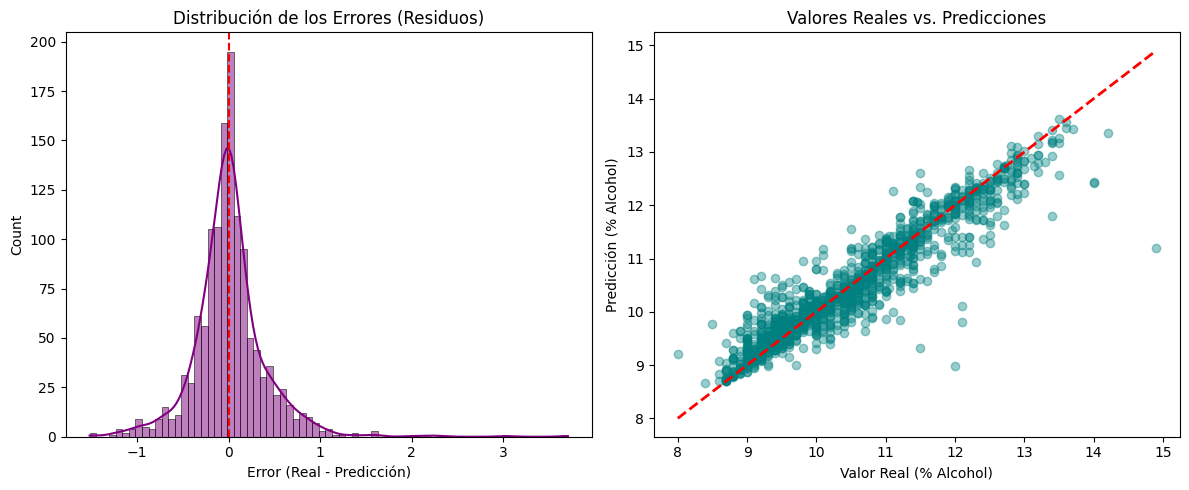

In [8]:
# MODELADO PARA REGRESIÓN

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error, make_scorer
from sklearn.ensemble import RandomForestRegressor
# Si no tengo instalados XGBoost o LightGBM, puedo usar GradientBoostingRegressor de sklearn!!
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

# 1. Separar variables para regresión (Alcohol es el target)
X_reg = df.drop(columns=['alcohol'])
y_reg = df['alcohol']

# 2. División en conjuntos de entrenamiento y test
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# 3. Escalado de características (esencial para modelos lineales o basados en distancias)
scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

# 4. Definir el "scorer" para validación cruzada usando MAPE
# scikit-learn minimiza los scores por defecto, por lo que cross_val_score los devuelve negativos
mape_scorer = make_scorer(mean_absolute_percentage_error, greater_is_better=False)

print("--- Evaluando Modelos con Validación Cruzada (Métrica: MAPE) ---")

# Definimos 3 tipos de modelos distintos
modelos_reg = {
    "Regresión Lineal (Baseline)": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(random_state=42, n_estimators=100),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42)
}

for nombre, modelo in modelos_reg.items():
    # Usamos los datos escalados
    scores = cross_val_score(modelo, X_train_r_scaled, y_train_r, cv=5, scoring=mape_scorer)
    # Convertimos a positivo y multiplicamos por 100 para ver el porcentaje real de error
    mape_medio = -scores.mean() * 100 
    print(f"{nombre} - MAPE medio en CV: {mape_medio:.2f}%")

# 5. Optimización de Hiperparámetros (GridSearchCV) para el mejor modelo candidato
# Elegimos RandomForest para el ejemplo
print("\n--- Optimizando el Modelo Elegido ---")
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf, cv=5, scoring=mape_scorer, n_jobs=-1)
grid_rf.fit(X_train_r_scaled, y_train_r)

best_rf_reg = grid_rf.best_estimator_
print(f"Mejor MAPE en CV tras optimizar: {-grid_rf.best_score_ * 100:.2f}%")

# 6. Evaluación Final en el conjunto de Test
y_pred_r = best_rf_reg.predict(X_test_r_scaled)
mape_test = mean_absolute_percentage_error(y_test_r, y_pred_r) * 100
print(f"\n===========================================")
print(f"MAPE FINAL EN EL CONJUNTO DE TEST: {mape_test:.2f}%")
print(f"===========================================")

# 7. Análisis de Errores (Residuos)
errores = y_test_r - y_pred_r

plt.figure(figsize=(12, 5))

# Gráfico 1: Distribución de los errores
plt.subplot(1, 2, 1)
sns.histplot(errores, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribución de los Errores (Residuos)")
plt.xlabel("Error (Real - Predicción)")

# Gráfico 2: Valores Reales vs Predicciones
plt.subplot(1, 2, 2)
plt.scatter(y_test_r, y_pred_r, alpha=0.4, color='teal')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2)
plt.title("Valores Reales vs. Predicciones")
plt.xlabel("Valor Real (% Alcohol)")
plt.ylabel("Predicción (% Alcohol)")

plt.tight_layout()
plt.show()

1. Análisis de los Modelos y Métricas (MAPE)  
El negocio pedía equivocarse lo menos posible porcentualmente sobre el grado alcohólico real.  
Comparativa inicial en Validación Cruzada (CV):
- Regresión Lineal: $3.37\%$ de error medio.
- Gradient Boosting: $3.48\%$ de error medio.
- Random Forest Regressor: $2.68\%$ de error medio.    

Resultado Final en Test: Tras optimizar hiperparámetros, el modelo alcanza un MAPE final de $2.49\%$.Interpretación: Un MAPE de $2.49\%$ es un resultado extraordinario para este tipo de datos químicos. Significa que si un vino tiene realmente un $12\%$ de grado alcohólico, el modelo se equivoca, en promedio, únicamente unas décimas ($\pm 0.3\%$ de alcohol). El modelo es sumamente preciso y cumple de sobra con un estándar comercial útil.

2. Análisis Visual de Errores  
Gráfico 1: Distribución de los Errores (Residuos)Lo que observamos: La curva morada tiene una forma de campana (distribución normal) casi perfecta y está muy bien centrada en la línea discontinua roja del $0$.  
Conclusión: Al estar centrada en cero, confirmamos que el modelo no tiene sesgo sistemático (es decir, no tiende a predecir siempre por encima ni siempre por debajo de la realidad). La gran mayoría de los errores se agrupan estrechamente entre $-0.5$ y $0.5$.  
Gráfico 2: Valores Reales vs. PrediccionesLo que observamos: La inmensa mayoría de los puntos turquesa se concentran y siguen fielmente la línea diagonal roja discontinua (la línea de predicción perfecta).El detalle de los "Outliers" (Valores atípicos): Si nos fijamos en el extremo derecho, hay un punto aislado que representa un vino con casi un $15\%$ de alcohol, pero el modelo lo estimó cercano al $11.2\%$.


##  Conclusión y Cierre de la Práctica  
Análisis de Errores de Regresión: El modelo final seleccionado ha sido Random Forest Regressor, logrando reducir el error porcentual medio (MAPE) a un excelente $2.49\%$ en el conjunto de test independiente.  
El análisis de residuos confirma la robustez del modelo, mostrando una distribución simétrica y centrada en $0$. No obstante, se observa que el modelo tiende a subestimar el contenido alcohólico en vinos con graduaciones extremadamente altas (cercanas al $15\%$). Esto es normal debido a la escasez de ejemplos con valores tan extremos en el dataset de entrenamiento. En líneas generales, el modelo es altamente fiable para la simulación de nuevas variedades de vino.